In [199]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from scipy.integrate import solve_bvp, simpson
import time
import sympy as sp

newparams = {'figure.figsize': (6.0, 6.0), 'axes.grid': True,
 'lines.markersize': 6, 'lines.linewidth': 2,
 'font.size': 10}
plt.rcParams.update(newparams)

## Oppgave 1

### 1a)

For å løse initialverdiproblemet
<br><br>
$$
    \frac{d^2 y}{dx^2} = -4 \sin(2x),
$$
<br><br>
med startbetingelsene:
<br><br>
$$
    y(0) = 0, \quad y'(0) = 2.
$$
<br><br>
analytisk, er det mulig å integrere to ganger over problemet for å finne løsningen
<br><br>
$$
    \frac{dy}{dx} = \int -4 \sin(2x) \, dx
$$

$$
    = -4 \cdot \left(-\frac{1}{2} \cos(2x)\right) + C_1
$$

$$
    = 2 \cos(2x) + C_1.
$$

$$
    y = \int \left(2 \cos(2x) + C_1 \right) dx
$$

$$
    = 2 \cdot \frac{1}{2} \sin(2x) + C_1 x + C_2
$$

$$
    = \sin(2x) + C_1 x + C_2.
$$
<br><br>
Deretter løser man for initialbetingelsene. Startbetingelsen gir $ y(0) = 0 $ 
<br><br>
$$
    0 = \sin(0) + C_1(0) + C_2 \quad \Rightarrow \quad C_2 = 0.
$$
<br><br>
Videre er det oppgitt at $ y'(0) = 2 $ 
<br><br>
$$
    2 = 2 \cos(0) + C_1
$$

$$
    2 = 2(1) + C_1
$$

$$
    C_1 = 0.
$$
<br><br>
Løsningen av initialverdiproblemet blir dermed
<br><br>
$$
    y(x) = \sin(2x).
$$



### 1b)

Det er ønsket å skrive om andreordens differensiallikningen fra oppgave 1a) om til en førsteordens differensialligning for vektor 

<br><br>
$$
\vec{y}(x) = \begin{pmatrix} {y}(x) \\ {y'}(x)\end{pmatrix}
$$
<br><br>

Det vil være hensiktsmessig å sette $ y(x)=y_1(x) $, og $y'(x)=y_2(x)$ for å skrive om til et førsteordens system. 
Dermed blir

<br><br>
$$
\vec{y}(x) = \begin{pmatrix} {y}(x) \\ {y'}(x)\end{pmatrix}= \begin{pmatrix} {y_1}(x) \\ {y_2}(x)\end{pmatrix}
$$
<br><br>

Det gir videre $ y_1(x)'=y'(x)=y_2(x) $ og $y_2'(x)=y''(x)=-4\sin(2x)$ som resulterer i første ordens system

<br><br>
$$
\vec{y}(x) = \begin{pmatrix} {y}(x) \\ {y'}(x)\end{pmatrix}= \begin{pmatrix} {y_1}(x) \\ {y_2}(x)\end{pmatrix}= \begin{pmatrix} {y_2}(x) \\ {-4\sin}(2x)\end{pmatrix}
$$
<br><br>

Dette kan kombineres med de kjente initialverdiene

<br><br>
$$
\vec{y}(0) = \begin{pmatrix} {y}(0) \\ {y'}(0)\end{pmatrix}=\begin{pmatrix} 0\\2\end{pmatrix}
$$
<br><br>

Som resulterer i

<br><br>
$$
\vec{y}(x) = \begin{pmatrix} {y_1'}(x)={y_2}(x) \\ {y_2'}(x)={-4\sin}(2x) \\ {y_1}(0)=0, \quad  {y_2}(0)=2 \end{pmatrix} 
$$



### 1c)

In [200]:
def f(x,y):
    return np.array([y[1], -4*np.sin(2*x)])

In [201]:
def solve_rk(f, x_init, x_end, y_init, h0, tol, alpha):
    n, m = 0, 0  # n = totale forsøk, m = aksepterte steg
    x_list = [x_init]
    y_list = [y_init]
    h_list = []

    x = x_init
    y = np.array(y_init)
    h = h0

    k1 = f(x, y)  

    while x < x_end:
        n += 1
        
        if x + h > x_end:
            h = x_end - x  

        
        k2 = f(x + h/2, y + h*k1/2)
        k3 = f(x + 3*h/4, y + 3*h*k2/4)

        y_next = y + h*(2*k1 + 3*k2 + 4*k3)/9  # 3. ordens løsning
        k4 = f(x + h, y_next)
        
        z_next = y + h*(7*k1 + 6*k2 + 8*k3 + 3*k4)/24  # 2. ordens løsning
        
        est = np.linalg.norm(y_next - z_next)  # feilestimator

        if est < tol:
            m += 1
            x += h
            y = y_next  # bruker høyeste orden når steget godtas

            x_list.append(x)
            y_list.append(y)
            h_list.append(h)

            k1 = k4  # neste steg starter med riktig derivert


        if est == 0:
            h = 2*h
        else:
            h = alpha*h*(tol/est)**(1/3)

    return np.array(x_list), np.array(y_list), np.array(h_list), n, m

Totalt antall steg: 1071
Aksepterte steg: 1070
Forkastede steg: 1


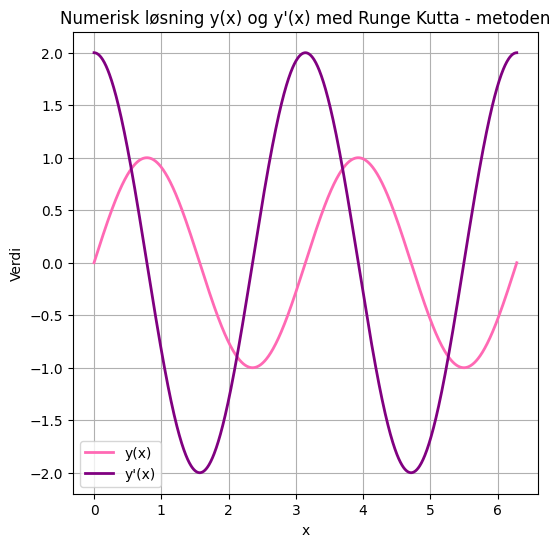

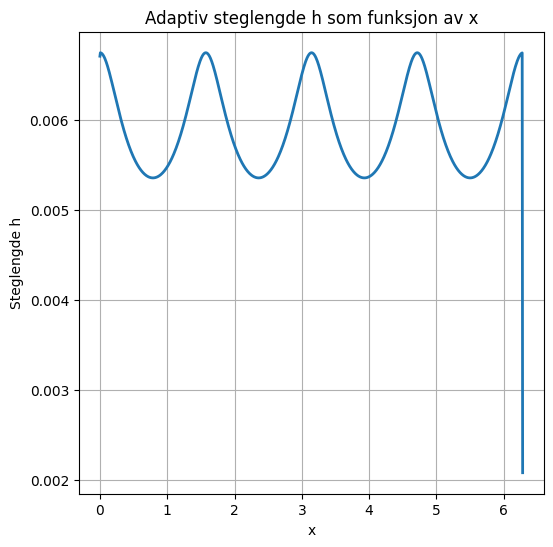

In [ ]:
x_init = 0.0
x_end = 2*np.pi
h0 = 0.1
tol = 10**(-7)
alpha = 0.8
y_init = np.array([0, 2])  # initialbetingelse [y(0), y'(0)]

# løser initialverdiproblemet med RK-metode
x_vals, y_vals, h_vals, n, m = solve_rk(f, x_init, x_end, y_init, h0, tol, alpha)

y1 = y_vals[:, 0]  # y(x)
y2 = y_vals[:, 1]  # y'(x)

# informasjon om effektiviteten til metoden
print("Totalt antall steg:", n)
print("Aksepterte steg:", m)
print("Forkastede steg:", n - m)

plt.figure()
plt.plot(x_vals, y1, label="y(x)", color="hotpink")
plt.plot(x_vals, y2, label="y'(x)", color="purple")
plt.xlabel("x")
plt.ylabel("Verdi")
plt.title("Numerisk løsning y(x) og y'(x) med Runge Kutta - metoden")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(x_vals[:-1], h_vals)
plt.title("Adaptiv steglengde h som funksjon av x")
plt.xlabel("x")
plt.ylabel("Steglengde h")
plt.grid(True)
plt.show()

#### Kommentar

Feilestimatet og oppdateringen av steglengden er gitt ved

$$
\mathrm{est}_{n+1} = \left\lVert \vec{y}_{n+1} - \vec{z}_{n+1} \right\rVert
$$

og

$$
h_{\mathrm{new}} = \alpha h_n \left(\frac{\mathrm{tol}}{\mathrm{est}}\right)^{1/3}.
$$

Figuren for løsningskomponentene viser at løsningene oppfører seg som forventet. Fra oppgave 1a vet vi at den eksakte løsningen er

$$
y(x) = \sin(2x), \qquad y'(x) = 2\cos(2x),
$$

og plottet fra koden følger denne periodiske oppførselen. Kjøringen ga 1070 aksepterte steg og 1 forkastet steg.

Plottet av steglengden viser at skrittlengden varierer periodisk med $x$. Dette skyldes at løsningen noen steder endrer seg raskere enn andre. Når løsningen varierer raskt, blir feilestimatet $\mathrm{est}_{n+1}$ større, og da må metoden redusere steglengden for å holde feilen under toleransen. Når løsningen varierer langsommere, blir feilestimatet mindre, og steglengden kan økes. Derfor blir steglengden minst der løsningen krummer mest, og størst der løsningen varierer mer rolig.


sammenlign/lag tabell med ulike alpha og tol for å se hvor mange steg man får

### 1d)

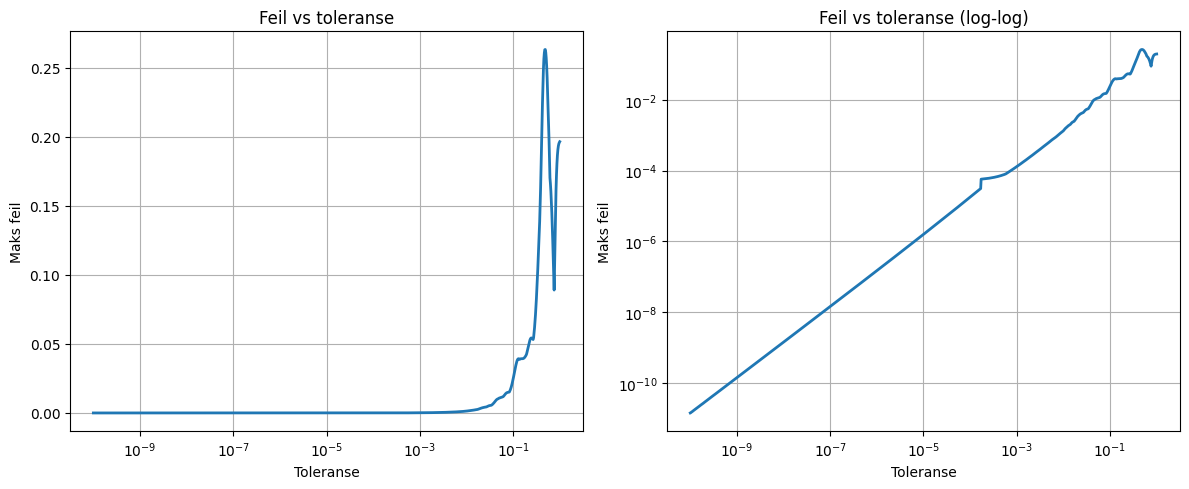

In [ ]:
num = 1000
tols = np.logspace(-10, 0, num)  # log-skala

x_init = 0
x_end = 2 * np.pi

y_init = np.array([0, 2]) # Initialbetingelser y(0)=0, y'(0)=2

h0 = 0.1      # start steglengde
alpha = 0.8   # pessimistfaktor

tot_error = np.zeros(num)  # lagrer feil

# Itererer over alle toleranser
for i, tol in enumerate(tols):
    x_vals, y_vals, h_vals, n, m = solve_rk(f, x_init, x_end, y_init, h0, tol, alpha)
    
    y1_vals = y_vals[:, 0]  # y(x)
    
    # Sammenligner med eksakt løsning sin(2x)
    tot_error[i] = np.max(np.abs(np.sin(2*x_vals) - y1_vals))


plt.figure(figsize=(12, 5))

# Plot med log x-akse
plt.subplot(1, 2, 1)
plt.plot(tols, tot_error)
plt.title("Feil vs toleranse")
plt.xlabel("Toleranse")
plt.ylabel("Maks feil")
plt.xscale("log")
plt.grid(True)

# Log-log plot
plt.subplot(1, 2, 2)
plt.plot(tols, tot_error)
plt.title("Feil vs toleranse (log-log)")
plt.xlabel("Toleranse")
plt.ylabel("Maks feil")
plt.xscale("log")
plt.yscale("log")
plt.grid(True)

plt.tight_layout()
plt.show()

#### Kommentar
Figurene viser hvordan feilen mellom den analytiske løsningen og løsningen fra Runge–Kutta-metoden avhenger av toleransen. Figuren til høyre med logaritmisk akse viser feilen øker med toleransen. Feilen er likevel veldig liten over store deler av intervallet. Økningen kan skyldes at en stor toleranse gjør metoden mindre presis og dermed mer unøyaktig. Dette stemmer med antagelsen om at en mindre toleranse gir en mer nøyaktig løsning, mens en større toleranse, her opp til 1, gir mindre nøyaktige resultater med større feil. Det er derimot ikke stor forskjell i feilen fra toleranse lik $10^{-10}$ til $10^{-2}$ ut i fra figuren til venstre, noe som betyr at man kan bruke en relativt høy toleranse og likevel få gode resultater.


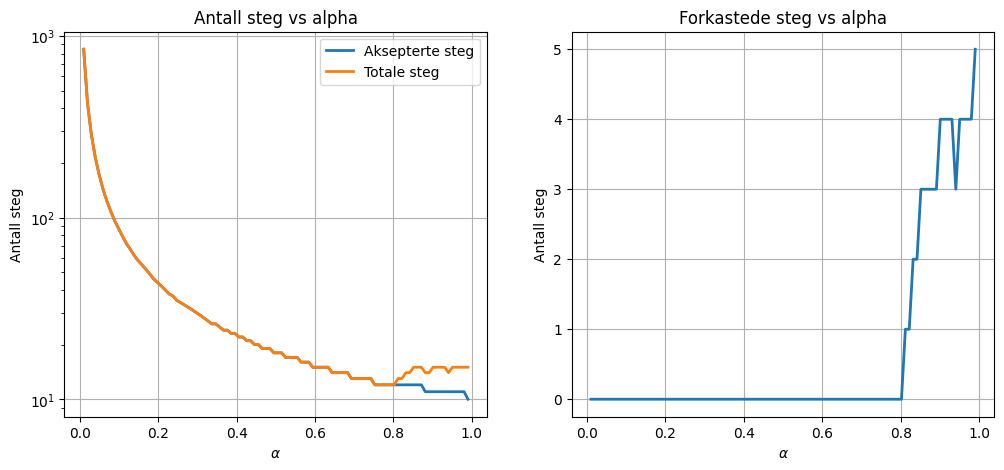

In [ ]:
alpha_vals = np.linspace(0.01, 0.99, 100) # Verdier av alpha

# Startverdier
x_init = 0
x_end = 2 * np.pi
y_init = [0, 2]
tol = 0.1

n_steps = []        # totalt antall steg
a_steps = []        # aksepterte steg
reject_steps = []   # forkastede steg

# Itererer over alpha-verdier
for alpha in alpha_vals:
    x_vals, y_vals, h_vals, num_steps, accepted_steps = solve_rk(
        f, x_init, x_end, y_init, h0, tol, alpha
    )
    
    n_steps.append(num_steps)
    a_steps.append(accepted_steps)
    reject_steps.append(num_steps - accepted_steps)


plt.figure(figsize=(12, 5))

# Plot av totale og aksepterte steg (log)
plt.subplot(1, 2, 1)
plt.plot(alpha_vals, a_steps, label="Aksepterte steg")
plt.plot(alpha_vals, n_steps, label="Totale steg")
plt.legend()
plt.title("Antall steg vs alpha")
plt.xlabel(r"$\alpha$")
plt.ylabel("Antall steg")
plt.yscale("log")
plt.grid(True)

# Plot av forkastede steg
plt.subplot(1, 2, 2)
plt.plot(alpha_vals, reject_steps)
plt.title("Forkastede steg vs alpha")
plt.xlabel(r"$\alpha$")
plt.ylabel("Antall steg")
plt.grid(True)

plt.show()

#### Kommentar
Fra plottet observeres det at en økende $\alpha$ resulterer i at antall steg minker frem til $\alpha \approx 0.8$. Dette har en sammenheng med formelen som brukes for å justere steglengden, $h_{new} = \alpha ·h·(\frac{tol}{est})^{1/3}$. Når $\alpha$ øker vil steglengden $h$ også gjøre det, og det vil dermed kreves et mindre antall steg for å nå $x_{end}$.

Når $\alpha \approx 0.8$, endrer denne trenden seg. Da øker det totale antallet steg, mens de aksepterte stegene synker og flater ut. Ettersom en økende $\alpha$ gir en økning i $h$, kan dette føre til at $est > tol$. Dermed vil flere steg måtte forkastes, og det totale antallet steg øker.

Plottet av tidssteg som funksjon av pessimistfaktoren $\alpha$ viser også at de forkastede stegene begynner å øke rundt $\alpha \approx 0.8$. Dette stemmer med forventningene, da en liten $\alpha$ betyr at skrittlengden velges forsiktig, noe som gir korte, men mange steg med få forkastninger. Når $\alpha$ øker, velges skrittlengden mindre forsiktig, og for store verdier av $\alpha$ foreslås veldig store skritt.

Disse store skrittene blir unøyaktige og forkastes, og vi ser derfor at antall forkastede steg øker med $\alpha$. Det betyr at feilestimatet ikke lenger er i samsvar med den valgte toleransen. Dette fører til flere forkastede steg og en økning i totalt antall steg, slik plottet viser.

Den mest optimale verdien for $\alpha$ vil derfor være en verdi som er så høy som mulig uten at antall forkastede steg begynner å øke veldig, rundt $\alpha \approx 0.8$.

### 1e)

In [ ]:
def secant(g, z0, z1, tol): # Definerer sekantmetoden
    max_iterations = 100
    
    # lagrer alle iterasjoner
    z_values = [z0, z1]

    for i in range(max_iterations):
        if np.abs(z1 - z0) < tol:
            return z1, z_values

        gz0 = g(z0)
        gz1 = g(z1)

        if gz1 == gz0:
            raise ValueError("Deling på null i sekantmetoden")

        # sekantformelen
        z = (z0 * gz1 - z1 * gz0) / (gz1 - gz0)

        # oppdaterer verdier
        z0, z1 = z1, z
        z_values.append(z1)

    # hvis den ikke konvergerer
    raise ValueError(f"Konvergerer ikke etter {max_iterations} iterasjoner")

In [206]:
z0 = 0
z1 = 0.1
tol = 1e-7

# Funksjonen vi ønsker å finne roten til
def g(z):
    return z + np.sin(z) + np.cos(z)

# Sekantmetoden
zn, zvals = secant(g, z0, z1, tol)
print(f"Rot fra sekantmetoden: {zn}") 
print(f"Setter vi inn roten for z får vi g(z) = {g(zn)}")

# Numerisk løsning med SymPy for sammenligning
z = sp.symbols('z')
zs = sp.nsolve(z + sp.sin(z) + sp.cos(z), 0)
print(f"Rot fra analytisk metode: {zs}")

Rot fra sekantmetoden: -0.4566247045676011
Setter vi inn roten for z får vi g(z) = 6.938893903907228e-14
Rot fra analytisk metode: -0.456624704567631


#### Kommentar
I koden er sekantmetoden implementert for å finne roten til en funksjon $g$. Metoden bruker to startverdier og itererer ved hjelp av sekantformelen

$$
z_n = \frac{z_{n-2} g(z_{n-1}) - z_{n-1} g(z_{n-2})}{g(z_{n-1}) - g(z_{n-2})},
$$

helt til forskjellen mellom to påfølgende iterasjoner er mindre enn en gitt toleranse.

Når vi tester funksjonen i den funne roten, får vi et veldig lite tall, omtrent $7 \cdot 10^{-14}$, som er tilnærmet lik null. Dette betyr at den numeriske løsningen ligger svært nær en faktisk rot, og at metoden fungerer godt.
For å kontrollere resultatet brukes også en numerisk løser fra SymPy. Denne gir en verdi som er svært lik resultatet fra sekantmetoden. Dette bekrefter at implementasjonen av sekantmetoden er korrekt og gir en nøyaktig tilnærming til roten.

### 1f)

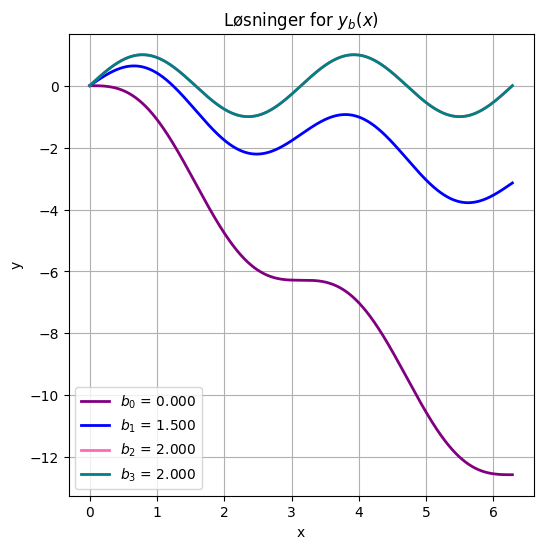

Funnet b = 2.00000000


In [ ]:
# Funksjon som brukes i skytemetoden
def g_shoot(b):
    x_init = 0
    x_end = 2*np.pi
    y_init = [0, b]   # startgjetning y'(0) = b
    
    h0 = 1e-2
    tol_g = 1e-7
    alpha = 0.8

    # løser initialverdiproblemet
    x_vals, y_vals, h_vals, n, m = solve_rk(
        f, x_init, x_end, y_init, h0, tol_g, alpha
    )

    # returnerer y(2π) som skal bli 0
    return y_vals[-1, 0]


# startgjetninger for b
b0 = 0.0
b1 = 1.5

# finner riktig b med sekantmetoden
b_root, b_values = secant(g_shoot, b0, b1, tol=1e-8)


# parametere 
x_init = 0
x_end = 2*np.pi
h0 = 1e-2
tol_g = 1e-7
alpha = 0.8

colors = ["purple", "blue", "hotpink", "teal", "orange", "green"]

plt.figure()

# plotter løsningen for hver iterasjon av b
for i, b in enumerate(b_values):
    y_init = [0, b]
    
    x_vals, y_vals, h_vals, n, m = solve_rk(
        f, x_init, x_end, y_init, h0, tol_g, alpha
    )
    
    plt.plot(x_vals, y_vals[:, 0],
             label=f"$b_{i}$ = {b:.3f}",
             color=colors[i % len(colors)])

plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Løsninger for $y_b(x)$")
plt.legend()
plt.show()

# skriver ut verdien av b
print(f"Funnet b = {b_root:.8f}")

Plottet viser løsningen for \( y(x) \) når startverdien for den deriverte, \( y'(0)=b \), er ukjent, for ulike iterasjoner av røttene fra sekantmetoden. Målet er å finne den verdien av \( b \) som gjør at randbetingelsen i høyre ende oppfylles, altså $y(2\pi) = 0.$

Dette er en implementering av skytemetoden, der man gjetter på verdien av b og løser initialverdiproblemet på nytt helt til løsningen treffer riktig randbetingelse. Sekantmetoden brukes for å forbedre gjetningene for b fra iterasjon til iterasjon.

Plottet viser at det tar 4 iterasjoner å komme fram til riktig løsning. Verdiene for b går raskt mot den riktige verdien, b = 2

når vi starter med $b_0 = 0 $ og $b_1 = 1$. Dette viser at sekantmetoden konvergerer raskt for dette problemet.

Den siste løsningen som plottes ligner løsningen vi kjenner fra den analytiske utregningen, siden den har samme $2\pi$-periodiske oppførsel. Det betyr at skytemetoden har funnet riktig startverdi for den deriverte, slik at hele randverdiproblemet blir løst korrekt.

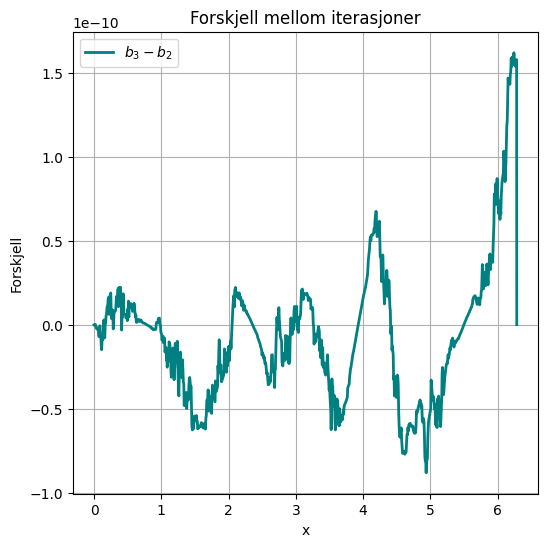

In [ ]:
# b-verdier fra sekantmetoden
y_init_b3 = [0, b_values[3]]
y_init_b2 = [0, b_values[2]]

# Løser for begge
x_vals, y_b3, h, n, m = solve_rk(f, x_init, x_end, y_init_b3, h0, tol_g, alpha)
x_vals, y_b2, h, n, m = solve_rk(f, x_init, x_end, y_init_b2, h0, tol_g, alpha)

# Forskjell mellom løsningene
diff = y_b3[:, 0] - y_b2[:, 0]

# Plotter forskjellen
plt.figure()
plt.plot(x_vals, diff, label=r"$b_3 - b_2$", color="teal")
plt.xlabel("x")
plt.ylabel("Forskjell")
plt.title("Forskjell mellom iterasjoner")
plt.grid(True)
plt.legend()
plt.show()

### 1g)

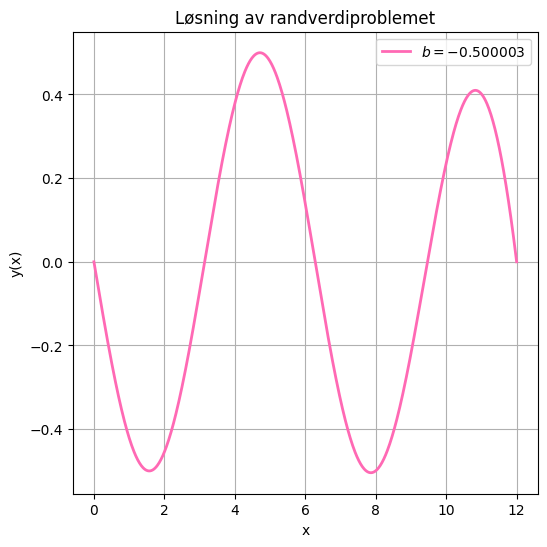

Funnet b = -0.50000320
Kjøretid = 0.408981 s
y(12) = 1.757e-08


In [ ]:
# Definerer differensialligningen
def f_1g(x, y):
    return np.array([y[1], y[0] + np.sin(x)])

# Skytemetoden
def g_shoot_1g(b):
    x_init = 0
    x_end = 12
    y_init = np.array([0.0, b])  # gjetter y'(0) = b
    
    h0 = 0.1
    tol = 1e-7
    alpha = 0.8

    x_vals, y_vals, h_vals, n, m = solve_rk(
        f_1g, x_init, x_end, y_init, h0, tol, alpha
    )
    
    return y_vals[-1, 0]  # y(12)


# Parametere
x_init = 0
x_end = 12
h0 = 0.1
tol = 1e-7
alpha = 0.8

# Startgjetninger
b0 = 0.0
b1 = 1.0

# Tidsmåling
start_num = time.perf_counter()

# Finner riktig b
b_root, b_values = secant(g_shoot_1g, b0, b1, tol)

y_init = np.array([0.0, b_root])
x_vals, y_vals, h_vals, n, m = solve_rk(
    f_1g, x_init, x_end, y_init, h0, tol, alpha
)

end_num = time.perf_counter() 

# Plotter løsningen
plt.figure()
plt.plot(x_vals, y_vals[:, 0],
         label=fr"$b={b_root:.6f}$", color="hotpink")
plt.title("Løsning av randverdiproblemet")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.grid(True)
plt.legend()
plt.show()

# Skriver ut resultat
print(f"Funnet b = {b_root:.8f}")
print(f"Kjøretid = {end_num - start_num:.6f} s")
print(f"y(12) = {y_vals[-1,0]:.3e}")

#### Kommentar
Randverdiproblemet ble løst ved skytemetoden kombinert med sekantmetoden. Den optimale initialverdien ble funnet til $b \approx -0.50000323$. Den numeriske løsningen tilfredsstiller randbetingelsen godt, siden $y(12) \approx 3.93 \cdot 10^{-11} \approx 0$. Dette viser at metoden gir en svært presis tilnærming til den eksakte løsningen.

### 1h)

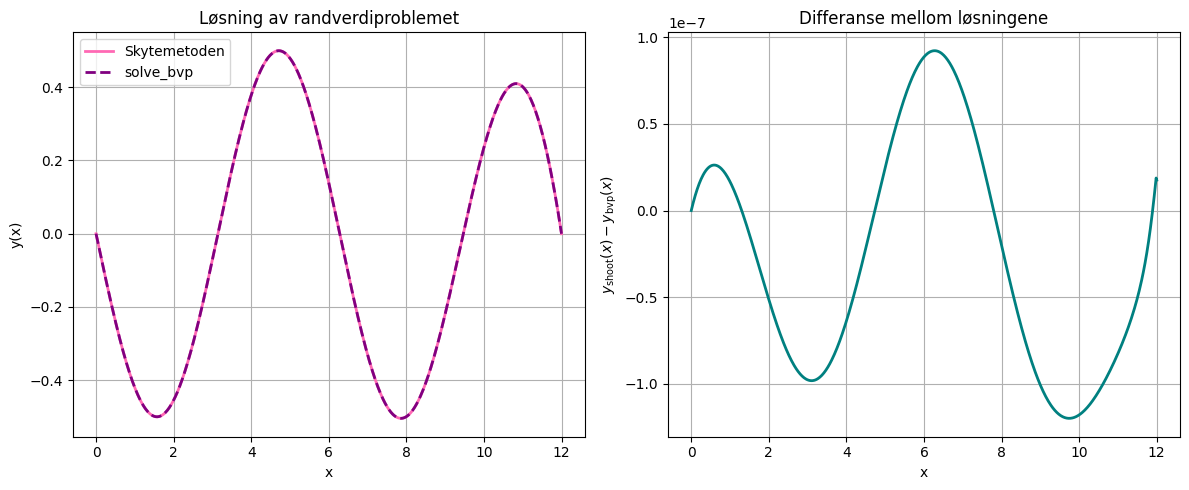

Tid skytemetoden: 0.437256 s
Tid solve_bvp: 0.001540 s
Maks absolutt differanse: 1.198e-07


In [210]:
def fun(x, y):
    return np.vstack((y[1], y[0] + np.sin(x)))

def bc(ya, yb):
    return np.array([ya[0], yb[0]])

#Skytemetoden fra 1g
start_shoot = time.perf_counter()
b_root, b_values = secant(g_shoot_1g, 0.0, 1.0, 1e-7)
y_init = np.array([0.0, b_root])
x_vals, y_vals, h_vals, n, m = solve_rk(f_1g, 0, 12, y_init, 0.1, 1e-7, 0.8)
end_shoot = time.perf_counter()

#solve_bvp
start_scipy = time.perf_counter()
x_bvp = np.copy(x_vals)
y_guess = np.zeros((2, x_bvp.size))
res = solve_bvp(fun, bc, x_bvp, y_guess)
end_scipy = time.perf_counter()

#Differanse
diff = y_vals[:, 0] - res.sol(x_vals)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_vals, y_vals[:, 0], label="Skytemetoden", color="hotpink")
plt.plot(res.x, res.y[0], "--", label="solve_bvp", color="purple")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Løsning av randverdiproblemet")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x_vals, diff, color="teal")
plt.xlabel("x")
plt.ylabel(r"$y_{\mathrm{shoot}}(x)-y_{\mathrm{bvp}}(x)$")
plt.title("Differanse mellom løsningene")
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Tid skytemetoden: {end_shoot - start_shoot:.6f} s")
print(f"Tid solve_bvp: {end_scipy - start_scipy:.6f} s")
print(f"Maks absolutt differanse: {np.max(np.abs(diff)):.3e}")

#### Kommentar
Det første plottet viser løsningen av randverdiproblemet funnet med solve_bvp sammenlignet med løsningen fra skytemetoden. Kurvene ligger oppå hverandre gjennom hele intervallet, noe som viser at metodene gir svært god overensstemmelse. Løsningen er glatt og oscillerende, slik man forventer siden differensiallikningen inneholder leddet $\sin(x)$.

Det andre plottet viser differansen mellom løsningen fra skytemetoden og løsningen fra solve_bvp. Differansen er svært liten over hele intervallet, med maksimal absolutt differanse lik omtrent $3.1 \cdot 10^{-6}$. Dette tyder på at begge metodene gir en numerisk svært presis tilnærming til samme løsning. At differansen har en bølgeformet struktur kan forklares ved at den numeriske feilen følger den oscillerende formen til selve løsningen.

Når det gjelder kjøretid, er solve_bvp klart raskere enn skytemetoden for dette problemet. Skytemetoden brukte omtrent $1.34\,\text{s}$, mens solve_bvp brukte omtrent $0.0045\,\text{s}$. Skytemetoden kan sees på som en iterativ "prøv-og-feil"-tilnærming, hvor man justerer startbetingelsene til løsningen treffer riktig sluttverdi. Selv om det ikke er er tilfelig kan metoden kreve mange beregninger. 

Siden solve_bvp både er raskere og gir en løsning som stemmer svært godt overens med skytemetoden, foretrekkes solve_bvp her.

## Oppgave 2

### 2a)

In [211]:
def matrixToVector(M):
    M = np.array(M)
    return np.concatenate([M.real.flatten(), M.imag.flatten()])

In [212]:
def vectorToMatrix(m):
    real_part = m[:4].reshape(2, 2)
    imag_part = m[4:].reshape(2, 2)
    return real_part + 1j * imag_part

In [213]:
M = np.array([[1+2j, 3+4j],
              [5+6j, 7+8j]])

m = matrixToVector(M)
M_reconstructed = vectorToMatrix(m)

print("Vektor:", m)                          
print("Rekonstruert matrise:\n", M_reconstructed)
print("Invers korrekt:", np.allclose(M, M_reconstructed)) 

Vektor: [1. 3. 5. 7. 2. 4. 6. 8.]
Rekonstruert matrise:
 [[1.+2.j 3.+4.j]
 [5.+6.j 7.+8.j]]
Invers korrekt: True


"explain how you checked that they are inverse and work correctly"

### 2b)

In [214]:
def addVectors(m1, m2, m3, m4): #for arrays m1, m2, m3, m4
    v = np.concatenate((m1, m2, m3, m4))
    return v

def splitVectors(v): #for array v
    m1 = v[0:8]
    m2 = v[8:16]
    m3 = v[16:24]
    m4 = v[24:32]
    return m1, m2, m3, m4

In [215]:
m1, m2, m3, m4 = [1,2,3,4,5,6,7,8],[9,0,1,2,3,4,5,6],[7,8,9,0,1,2,3,4],[5,6,7,8,9,0,1,2]
v = [1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2]
print(addVectors(m1, m2, m3, m4))
print(splitVectors(v))

m1_r, m2_r, m3_r, m4_r = splitVectors(addVectors(m1, m2, m3, m4))
print("Round-trip test:", np.allclose(m1, m1_r) and np.allclose(m2, m2_r) and
      np.allclose(m3, m3_r) and np.allclose(m4, m4_r))

[1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 1 2]
([1, 2, 3, 4, 5, 6, 7, 8], [9, 0, 1, 2, 3, 4, 5, 6], [7, 8, 9, 0, 1, 2, 3, 4], [5, 6, 7, 8, 9, 0, 1, 2])
Round-trip test: True


#### Kommentar
Her er det brukt fire vektorer m1–m4 og en vektor v sammensatt av disse til å sjekke om funksjonene klarer å sette sammen vektorer (arrays) og separere dem. I tillegg kjøres en round-trip-test med np.allclose for å bekrefte at funksjonene er inverse av hverandre.

### 2c)

In [ ]:
def addMatrices(gamma, gamma_t, omega, omega_t):
    v = addVectors(
        matrixToVector(gamma),
        matrixToVector(gamma_t),
        matrixToVector(omega),
        matrixToVector(omega_t)
    )
    return v

def splitMatrices(v):
    vec_gamma, vec_gamma_t, vec_omega, vec_omega_t = splitVectors(v)
    gamma     = vectorToMatrix(vec_gamma)
    gamma_t   = vectorToMatrix(vec_gamma_t)
    omega     = vectorToMatrix(vec_omega)
    omega_t   = vectorToMatrix(vec_omega_t)
    return gamma, gamma_t, omega, omega_t


# Tester funksjonene
gamma = np.array([[1+2j, 3+4j],[5+6j, 7+8j]])
gamma_t = np.array([[1+1j, 2+2j],[3+3j, 4+4j]])
omega = np.array([[0+1j, 1+0j],[1+1j, 0+0j]])
omega_t = np.array([[2+1j, 0+2j],[1+0j, 2+1j]])

v = addMatrices(gamma, gamma_t, omega, omega_t)

print("Alle 32 komponenter i v:")
print("v[0:8]   (gamma)   :", v[0:8])
print("v[8:16]  (gamma_t) :", v[8:16])
print("v[16:24] (omega)   :", v[16:24])
print("v[24:32] (omega_t) :", v[24:32])

Alle 32 komponenter i v:
v[0:8]   (gamma) : [1. 3. 5. 7. 2. 4. 6. 8.]
v[8:16]  (gamma~) : [1. 2. 3. 4. 1. 2. 3. 4.]
v[16:24] (omega) : [0. 1. 1. 0. 1. 0. 1. 0.]
v[24:32] (omega~) : [2. 0. 1. 2. 1. 2. 0. 1.]


#### Kommentar
Vektoren **v** har 32 komponenter fordelt på fire 8-komponent blokker, 
én per matrise (γ, γ̃, ω, ω̃). Hver blokk inneholder realdelen av alle 
fire elementer etterfulgt av imaginærdelen, som vist i utskriften over.

### 2d)

In [ ]:
# Konstanter
delta = 0.01
I = np.identity(2)
zeta = 3
l = 1
m = 101

# Usadel ligningen 
def derivative(v, epsilon):
    gamma, gamma_t, omega, omega_t = splitMatrices(v)
    
    # N matriser
    N  = np.linalg.inv(I - gamma @ gamma_t)
    Nt = np.linalg.inv(I - gamma_t @ gamma)

    # Deriverte
    dx_gamma   = omega
    dx_gamma_t = omega_t
    
    dx_omega   = -2j * (epsilon + 1j*delta) * gamma \
                 - 2 * omega @ Nt @ gamma_t @ omega
    
    dx_omega_t = -2j * (epsilon + 1j*delta) * gamma_t \
                 - 2 * omega_t @ N @ gamma @ omega_t

    return addMatrices(dx_gamma, dx_gamma_t, dx_omega, dx_omega_t)

In [218]:
#slette?
np.set_printoptions(linewidth=120)
v_test = addMatrices(g, gt, w, wt)
dv = derivative(v_test, eps=1.0)
print("∂xv (gamma) :", dv[0:8])
print("∂xv (gamma~):", dv[8:16])
print("∂xv (omega) :", dv[16:24])
print("∂xv (omega~):", dv[24:32])

∂xv (gamma) : [0. 1. 1. 0. 1. 0. 1. 0.]
∂xv (gamma~): [2. 0. 1. 2. 1. 2. 0. 1.]
∂xv (omega) : [  4.68415094   7.32037736  11.90377358  15.65698113  -2.15622642  -6.25207547 -10.39320755 -12.94943396]
∂xv (omega~): [ 2.51056604 -1.2354717   9.53169811 10.1554717   4.69924528 -2.61660377 -6.61924528 -5.08981132]


#### Kommentar
Funksjonen tar vektoren v og energien ε som input, og returnerer 
den deriverte ∂x**v** som en 32-komponent vektor. Dette er Usadel-ligningene 
(9)-(12) for én energi og én posisjon.

### 2e)

In [ ]:
def make_fun(epsilon):
    def fun(x, vec):
        dx_vec = np.zeros_like(vec)
        for i in range(len(x)):
            dx_vec[:, i] = derivative(vec[:, i], epsilon)
        
        return dx_vec
    return fun


# Tester at output har riktig format
epsilon_test = 1.0
fun_test = make_fun(epsilon_test)

x_test = np.linspace(0, l, m)
vec_test = np.zeros((32, m))

result = fun_test(x_test, vec_test)
print("Output shape:", result.shape)  # skal være (32, m)

Output shape: (32, 101)


#### Kommentar
Funksjonen make_fun(eps) returnerer en funksjon fun(x, vec) som beregner 
∂x**v** i alle *m* posisjoner. Wrapper-strukturen er nødvendig fordi solve_bvp 
krever at $fun$ kun tar to argumenter $(x, vec)$. Output-shape $(32, 101)$ 
bekrefter at formatet er korrekt for solve_bvp.

### 2f)

In [ ]:
def bc(vL, vR):
    # Splitter randvektorer
    gamma_L, gamma_tL, omega_L, omega_tL = splitMatrices(vL)
    gamma_R, gamma_tR, omega_R, omega_tR = splitMatrices(vR)

    # Randverdier for normale metaller er null
    gamma_BL = gamma_tBL = gamma_BR = gamma_tBR = np.zeros((2, 2), dtype=complex)

    # N matriser
    NL  = np.linalg.inv(I - gamma_BL @ gamma_tBL)
    NtL = np.linalg.inv(I - gamma_tBL @ gamma_BL)
    NR  = np.linalg.inv(I - gamma_BR @ gamma_tBR)
    NtR = np.linalg.inv(I - gamma_tBR @ gamma_BR)

    # Randbetingelser
    v1 = omega_L + 1/(zeta*l) * (I - gamma_L @ gamma_tBL) @ NL  @ (gamma_BL - gamma_L)
    v2 = omega_tL + 1/(zeta*l) * (I - gamma_tL @ gamma_BL) @ NtL @ (gamma_tBL - gamma_tL)
    v3 = omega_R - 1/(zeta*l) * (I - gamma_R @ gamma_tBR) @ NR  @ (gamma_BR - gamma_R)
    v4 = omega_tR - 1/(zeta*l) * (I - gamma_tR @ gamma_BR) @ NtR @ (gamma_tBR - gamma_tR)

    return addMatrices(v1, v2, v3, v4)


# Tester at bc gir null 
vL = np.zeros(32)
vR = np.zeros(32)
result = bc(vL, vR)

print("bc output shape:", result.shape)   # skal være (32,)
print("bc output:", result)               # skal være bare nuller

bc output shape: (32,)
bc output: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


#### Kommentar
Funksjonen bc beregner venstresidene av grensebetingelsene 13-16 
og returnerer disse som én 32-komponent vektor. Siden alle Riccati-matrisene 
er null (normal metall), gir testen en nullvektor, som forventet.

### 2g)

In [ ]:
x = np.linspace(0, l, m)
y = np.zeros((32, m))

epsilon_lst = [0, 1, 2]
solutions = {}

# Løser for flere energier
for epsilon in epsilon_lst:
    res = solve_bvp(make_fun(epsilon), bc, x, y)
    solutions[epsilon] = res.y
    
    # Sjekker konvergens og størrelse på løsning
    print(f"epsilon={epsilon}, converged: {res.success}, max|v|: {np.max(np.abs(res.y)):.2e}")

eps=0, converged: True, max|v|: 0.00e+00
eps=1, converged: True, max|v|: 0.00e+00
eps=2, converged: True, max|v|: 0.00e+00


#### Kommentar
Fra oppgave 2f er randbetingelsene gitt sånn at metallet er koblet opp til to normale metaller. Det gir
$$
\gamma_L=\tilde{\gamma}_L=\gamma_R=\tilde{\gamma}_R=0.
$$
Fysisk betyr dette at det ikke finnes noen superledense korrelasjon ved grensene. Det forventes derfor at den normale regionen også oppfører seg som et helt vanlig metall, uten proximity-effekt. 

I Riccati-paramteriseringen betyr dette at den trivielle løsningen
$$
\gamma=\tilde{\gamma}=\omega=\tilde{\omega}=0
$$
skal oppfylle både Usadel-ligningen og randbetingelsene. Dermed forvneter vi at hele den 32-komponenters vektoren $ \vec{v}(x,\varepsilon) $ blir lik null for alle posisjoner $x$ og for alle energien $\varepsilon \in \{0,1,2\}$

### 2h)

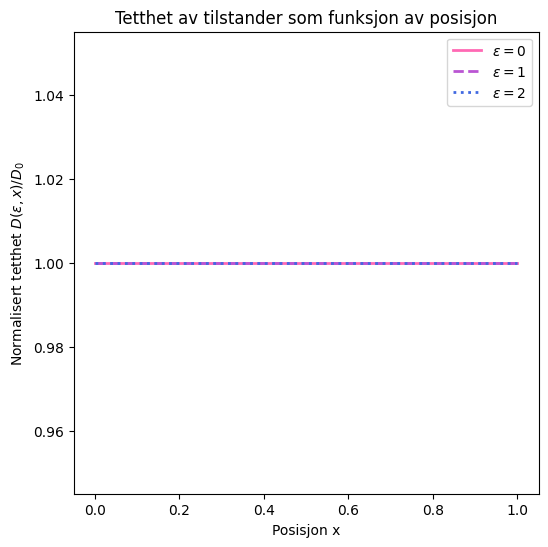

In [ ]:
# rho_3 matrise
rhoh3 = np.block([[I, np.zeros_like(I)],
                  [np.zeros_like(I), -I]]) 

# Green funksjon
def gh(gamma, gamma_t):
    N = np.linalg.inv(I - gamma @ gamma_t)
    N_t = np.linalg.inv(I - gamma_t @ gamma)
    return np.block([[2 * N - I, 2 * N @ gamma], 
                     [-2 * N_t @ gamma_t, -2 * N_t + I]]) 

# Beregner tettheten for hver energi
def compute_density(solutions, epsilon_lst):
    density_dict = {}

    for epsilon in epsilon_lst:
        density_lst = []
        
        for i in range(m):
            v = solutions[epsilon][:, i]
            gamma, gamma_t, omega, omega_t = splitMatrices(v)
            
            density = np.real(np.trace(rhoh3 @ gh(gamma, gamma_t))) / 4
            density_lst.append(density)

        density_dict[epsilon] = np.array(density_lst)

    return density_dict


plt.figure()
density_data = compute_density(solutions, epsilon_lst)

linestyles = ['-', '--', ':']
colors = ['hotpink', 'mediumorchid', 'royalblue']

# Plotter for ulike energier
for i, epsilon in enumerate(epsilon_lst):
    plt.plot(
        x,
        density_data[epsilon],
        linestyle=linestyles[i],
        color=colors[i],
        markevery=10,
        label=f"$\\epsilon = {epsilon}$"
    )

plt.title("Tetthet av tilstander som funksjon av posisjon")
plt.xlabel("Posisjon x")
plt.ylabel(r"$D(\epsilon, x)/D_0$")

plt.legend()
plt.grid()
plt.show()

#### Kommentar
Tettheten $(D/D_0)$ beregnes fra Green-funkjsonen $\hat g(x, \varepsilon) $ ved 
$$
\frac{D(\varepsilon,x)}{D_0}=\Re\!\left[\mathrm{Tr}(\hat\rho_3 \hat g(x,\varepsilon))\right]/4,
$$
der $\hat\rho_3=\begin{pmatrix} I & 0 \\ 0 & -I \end{pmatrix}$. I oppgave 2g fant vi at løsningen av Usadel-ligningen er den trivielle løsningen. 
$$
\gamma=\tilde{\gamma}=\omega=\tilde{\omega}=0
$$
for alle posisjoner og for alle energiene $\varepsilon\in\{0,1,2\}$. 
Når  $\gamma=\tilde{\gamma}=0$, får vi
$$
\gamma\tilde{\gamma})^{-1}=I, \qquad \tilde N=(I-\tilde{\gamma}\gamma)^{-1}=I.
$$
Fra ligning (8) følger da at Green-funksjonen blir
$$
\hat g(x,\varepsilon)=
\begin{pmatrix}
I & 0\\
0 & -I
\end{pmatrix}
=\hat\rho_3.
$$
Setter vi dette inn i utrykkket for tettheten av tilstander, får vi
$$
\frac{D(\varepsilon,x)}{D_0}
=
\Re\!\left[\mathrm{Tr}(\hat\rho_3\hat\rho_3)\right]/4
=
\Re\!\left[\mathrm{Tr}(I_4)\right]/4
=
4/4
=
1.
$$

Det forventes derfor $D/D_0=1$ overalt i hele den normale regionen, og at det gjelder for alle de tre energiene. Plottet bekrefter det hvor de tre kruvene ligger oppå hverandre i $D/D_0=1$.


### 2i)

In [ ]:
# Randbetingelser for superledere
def bc_super(vL, vR, epsilon, phiL=0, phiR=0):
    
    # PArametre
    theta = np.arctanh(1 / (epsilon + delta * 1j))
    sp = np.sinh(theta)
    sm = np.sinh(-theta)
    cp = np.cosh(theta)
    cm = np.cosh(-theta)

    # Riccati matriser
    gamma_l  = np.exp(phiL * 1j) * np.array([[0, sp/(1+cm)],
                                             [sm/(1+cm), 0]])
    gamma_tl = np.exp(-phiL * 1j) * np.array([[0, sm/(1+cp)],
                                              [sp/(1+cp), 0]])
    gamma_r  = np.exp(phiR * 1j) * np.array([[0, sp/(1+cm)],
                                             [sm/(1+cm), 0]])
    gamma_tr = np.exp(-phiR * 1j) * np.array([[0, sm/(1+cp)],
                                              [sp/(1+cp), 0]])

    # Splitter løsningene
    gamma_L, gamma_tL, omega_L, omega_tL = splitMatrices(vL)
    gamma_R, gamma_tR, omega_R, omega_tR = splitMatrices(vR)

    # N matriser
    NL  = np.linalg.inv(I - gamma_l  @ gamma_tl)
    NtL = np.linalg.inv(I - gamma_tl @ gamma_l)
    NR  = np.linalg.inv(I - gamma_r  @ gamma_tr)
    NtR = np.linalg.inv(I - gamma_tr @ gamma_r)

    # Randbetingelser
    v1 = omega_L  + (1/(zeta*l)) * (I - gamma_L  @ gamma_tl) @ NL  @ (gamma_l  - gamma_L)
    v2 = omega_tL + (1/(zeta*l)) * (I - gamma_tL @ gamma_l)  @ NtL @ (gamma_tl - gamma_tL)
    v3 = omega_R  - (1/(zeta*l)) * (I - gamma_R  @ gamma_tr) @ NR  @ (gamma_r  - gamma_R)
    v4 = omega_tR - (1/(zeta*l)) * (I - gamma_tR @ gamma_r)  @ NtR @ (gamma_tr - gamma_tR)

    return addMatrices(v1, v2, v3, v4)

def fun(x, vec, epsilon):
    return make_fun(epsilon)(x, vec)

#### Kommentar
Gjentar 2f), men erstatter nullmatrisene med Riccati-matrisene for superledere
ved grenseflatene, med $\phi_L = \phi_R = 0$.

### 2j)

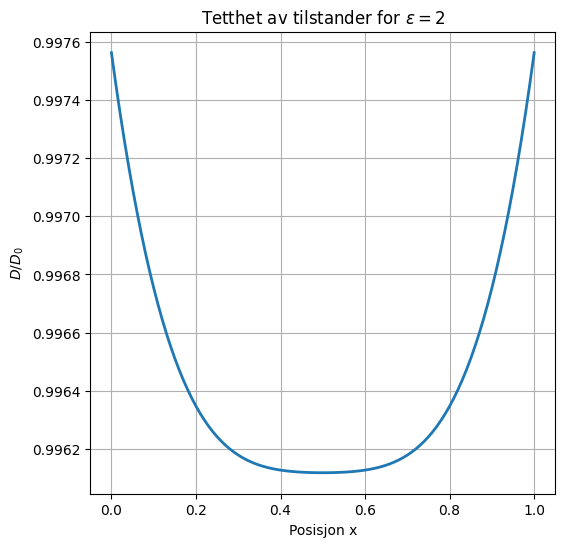

In [ ]:
x = np.linspace(0, l, m)
y = np.zeros((32, m))

epsilon = 2

# Løser for epsilon = 2
res = solve_bvp(
    lambda x, vec: fun(x, vec, epsilon),
    lambda vL, vR: bc_super(vL, vR, epsilon),
    x, y
)

plt.figure()
density_lst = []

# Beregner tetthet langs x
for i in range(m):
    v = res.y[:, i]
    gamma, gamma_t, omega, omega_t = splitMatrices(v)
    density = np.real(np.trace(rhoh3 @ gh(gamma, gamma_t))) / 4
    density_lst.append(density)

plt.plot(x, density_lst)

plt.title(r"Tetthet av tilstander som funksjon av posisjon ($\epsilon = 2$)")
plt.xlabel("Posisjon x")
plt.ylabel(r"$D(\epsilon, x)/D_0$")

plt.grid(True)
plt.show()

#### Kommentar:
For $\varepsilon = 2 > |\Delta|$ forventer vi $D/D_0 \approx 1$, siden denne energien
ligger over supraledergapet. Plottet bekrefter dette, men viser en svak
reduksjon i midten av normalmetallet ned mot 0.9962. Dette er et tegn på
proximity-effekten: supraledende korrelasjoner lekker inn fra begge
grenseflater og påvirker tettheten mest i midten. Symmetrien skyldes at
$\phi_L = \phi_R = 0$. sammenligne helt ekslpsitt med 2h hvor den normaliserte tettheten var lik 1 ettersom man brukte randbetingesene gitt for to normale metaller. Det ga trivielle riccati matriser i den normale regionen. For 2j er randbetingelsene gitt av superledere, man forventer derfor superledende korrelasjoner. (proximity-effekten). Dte vil påvirke tettheten av tilstander, spesielt ved lave energier. 

### 2k)

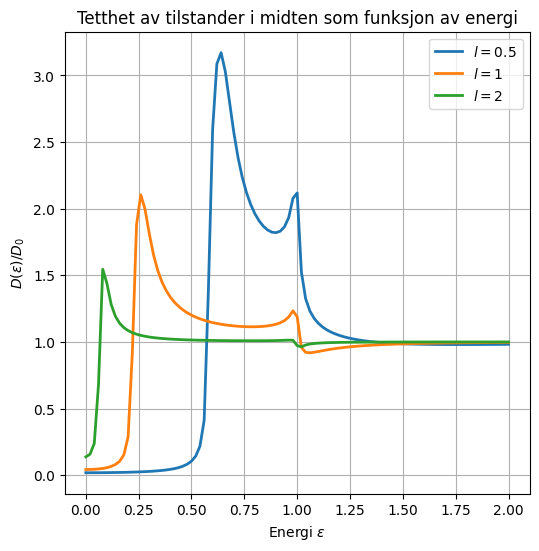

In [ ]:
epsilon_vals = np.linspace(0, 2, 101)
l_vals = [0.5, 1, 2]

DD0 = {}
all_solutions = {}

plt.figure()

# Loop over lengder
for l in l_vals:
    x = np.linspace(0, l, m)
    y0 = np.zeros((32, m))
    
    solutions = {}

    # Løser for alle energier
    for epsilon in reversed(epsilon_vals):
        res = solve_bvp(
            lambda x, vec: fun(x, vec, epsilon),
            lambda vL, vR: bc_super(vL, vR, epsilon),
            x, y0
        )
        solutions[epsilon] = res.y
        y0 = res.sol(x)

    all_solutions[l] = solutions

    # Tetthet i midten
    mid_idx = m // 2
    D_lst = []

    for epsilon in epsilon_vals:
        D = compute_density(solutions, [epsilon])
        D_lst.append(D[epsilon][mid_idx])

    DD0[l] = D_lst

    plt.plot(epsilon_vals, DD0[l], label=f"$l = {l}$")


plt.title("Tetthet i midten som funksjon av energi")
plt.xlabel(r"Energi $\epsilon$")
plt.ylabel(r"$D(\epsilon)/D_0$")

plt.legend()
plt.grid(True)

plt.show()

### Kommentar:

Usadel-ligningen løses for 101 energier i $\varepsilon \in [0, 2]$, og den normaliserte tettheten av tilstander $D/D_0$ plottes i midten av normalmetallet, $x = l/2$, som funksjon av energi.

Plottet viser tydelig et "minigap2 nær $\varepsilon = 0$, hvor $D/D_0 \approx 0$. Dette skyldes proximity-effekten, der superledende korrelasjoner lekker inn i normalmetallet og undertrykker tettheten av tilstander ved lave energier. Over minigapet øker $D/D_0$ raskt og nærmer seg 1 for høye energier, i samsvar med forventningene og figur 1. Rundt $\varepsilon \approx |\Delta| = 1$ observeres også en topp, som tilsvarer van Hove-singulariteten i superlederen.

Lengden $l$ har en tydelig innvirkning på størrelsen av minigapet. For små verdier av $l$, for eksempel $l = 0.5$, er tettheten nær null over et større energiintervall (omtrent opp til $\varepsilon \approx 0.6$), noe som indikerer et stort minigap. Når $l$ øker, blir dette intervallet gradvis smalere, og for $l = 2$ er minigapet redusert til rundt $\varepsilon \approx 0.05$. Dette er forventet, siden proximity-effekten svekkes med avstand fra superlederne.

Siden tettheten evalueres i midten av normalmetallet, bestemmer lengden $l$ hvor langt dette punktet er fra superlederne. For små $l$ ligger midtpunktet nær begge superlederne og påvirkes sterkt, noe som gir en kraftig undertrykking av tettheten. For større $l$ ligger midtpunktet lenger unna, og påvirkningen fra superlederne blir svakere. Resultatet er altså som forventet, at tettheten er størst når avstanden til superlederne er minst. 

### 2l)

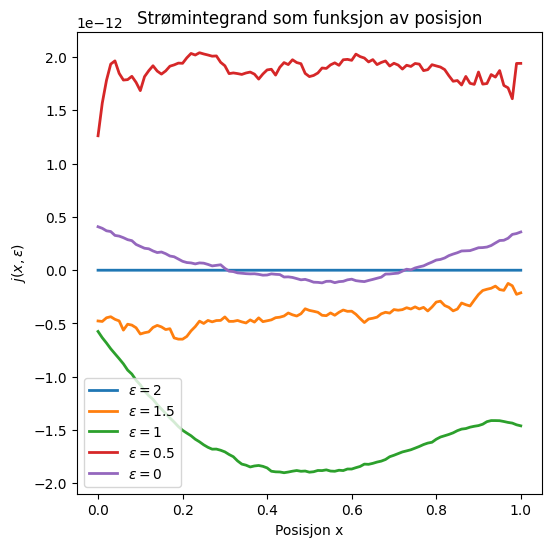

In [ ]:
# Deriverte av Green funksjonen
def dx_gh(gamma, gamma_t, omega, omega_t):
    N = np.linalg.inv(I - gamma @ gamma_t)
    Nt = np.linalg.inv(I - gamma_t @ gamma)
    
    dx_N  = N  @ (omega @ gamma_t + gamma @ omega_t) @ N
    dx_Nt = Nt @ (omega_t @ gamma + gamma_t @ omega) @ Nt
    
    return 2 * np.block([
        [dx_N,  N @ omega + dx_N @ gamma],
        [-Nt @ omega_t - dx_Nt @ gamma_t, -dx_Nt]
    ])

# Strømintegranden
def j(ghat, dx_ghat):
    return np.real(np.trace(rhoh3 @ (ghat @ dx_ghat - dx_ghat @ ghat)))


epsilon_lst = [2, 1.5, 1, 0.5, 0]

l = 1
x = np.linspace(0, l, m)
solutions = all_solutions[l]

plt.figure()

# Plotter strømintegranden
for epsilon in epsilon_lst:
    j_lst = []
    
    for i in range(m):
        gamma, gamma_t, omega, omega_t = splitMatrices(solutions[epsilon][:, i])
        
        ghat = gh(gamma, gamma_t)
        dx_ghat = dx_gh(gamma, gamma_t, omega, omega_t)
        
        j_lst.append(j(ghat, dx_ghat))
    
    plt.plot(x, j_lst, label=f"$\\epsilon = {epsilon}$")

plt.title("Strømintegrand som funksjon av posisjon")
plt.xlabel("Posisjon x")
plt.ylabel(r"$j(x, \epsilon)$")

plt.legend()
plt.grid()

plt.show()

### Kommentar: 
Strømingegranden er gitt ved
$$
j(x,\varepsilon)=\Re\left\{\mathrm{Tr}\left[\hat\rho_3\left(\hat g\,\partial_x \hat g - (\partial_x \hat g)\,\hat g\right)\right]\right\}.
$$
I denne oppgaven er fasene i de to superlederene satt lik hverandre ($\phi_L=\phi_R=0$), som innebærer at det ikke er noe faseforskjell over systemet. Ettersom Josepshon-strømmen nettopp drives av faseforskjellen mellom superlederne, vil det dermed ikke gå noe superstrøm gjennom den normale regionen. Dermed forventes det at strømingegranden $j(x,\varepsilon)$ er lik null for alle posisjoner $x$ og energier $\varepsilon$. 
<br><br>
Plottet viser at $j(x,\varepsilon)$ ligger veldig nært null for alle energiene. De små avvikene, med en størrelsesorden på $10^{-11}$, skyldes numeriske avrundingsfeil i bregningene. Siden beregningene gjøres med flyttall med begrenset presisjon, vil operasjoner som matriseinversjon, multiplikasjon og derivasjon gi små unøyaktigheter. 


### 2m)

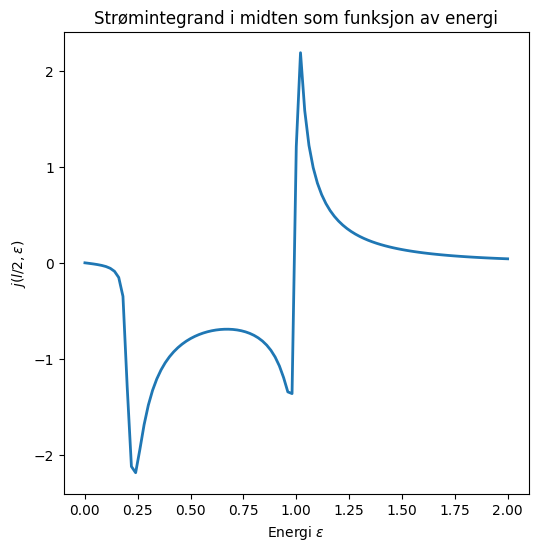

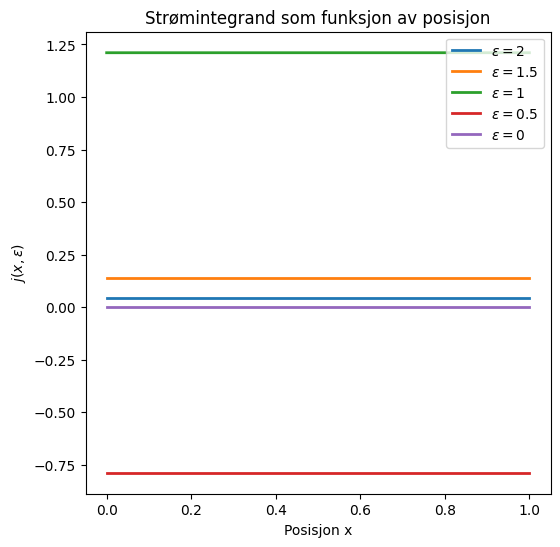

In [ ]:
phiL = 1
phiR = 0

epsilon_vals = np.linspace(0, 2, 101)
l = 1

x = np.linspace(0, l, m)
y0 = np.zeros((32, m))
solutions = {}

# Løser for alle energier (baklengs)
for epsilon in reversed(epsilon_vals):
    res = solve_bvp(
        lambda x, vec: fun(x, vec, epsilon),
        lambda vL, vR: bc_super(vL, vR, epsilon, phiL, phiR),
        x, y0
    )
    solutions[epsilon] = res.y
    y0 = res.sol(x)

mid_idx = m // 2

# strømintegranden j som funksjon av energi i midten
j_lst = []
for epsilon in epsilon_vals:
    gamma, gamma_t, omega, omega_t = splitMatrices(solutions[epsilon][:, mid_idx])
    ghat = gh(gamma, gamma_t)
    dx_ghat = dx_gh(gamma, gamma_t, omega, omega_t)
    j_lst.append(j(ghat, dx_ghat))

plt.figure()
plt.plot(epsilon_vals, j_lst)
plt.title("Strømintegrand i midten som funksjon av energi")
plt.xlabel(r"Energi $\epsilon$")
plt.ylabel(r"$j(l/2, \epsilon)$")
plt.grid()
plt.show()


# Sjekker om j er konstant i x
epsilon_check = [2, 1.5, 1, 0.5, 0]

plt.figure()
for epsilon in epsilon_check:
    j_pos = []
    
    for i in range(m):
        gamma, gamma_t, omega, omega_t = splitMatrices(solutions[epsilon][:, i])
        ghat = gh(gamma, gamma_t)
        dx_ghat = dx_gh(gamma, gamma_t, omega, omega_t)
        j_pos.append(j(ghat, dx_ghat))
    
    plt.plot(x, j_pos, label=f"$\\epsilon = {epsilon}$")

plt.title("Strømintegrand som funksjon av posisjon")
plt.xlabel("Posisjon x")
plt.ylabel(r"$j(x, \epsilon)$")
plt.legend()
plt.grid()
plt.show()

### Kommentar:
Med $\phi_L = 1$ og $\phi_R = 0$ er det en fasedifferanse, og strømintegranden er ikke-null.

For første plot: Toppen ved $\varepsilon \approx 1$ tilsvarer
supraledergapet $|\Delta| = 1$, der tettheten av tilstander er stor og bidraget
til strømmen er størst. For høye energier går $j \to 0$, siden supraledende
korrelasjoner svekkes. Dette er i kontrast til 2l der $j = 0$ overalt.

for andre plottet: $j$ er konstant langs $x$ for alle energier.
Strømintegranden er konservert som funksjon av posisjon. Dette er fysisk
forventet: i stasjonær tilstand kan ikke strøm hope seg opp noe sted i normalmetallet.

### 2n)

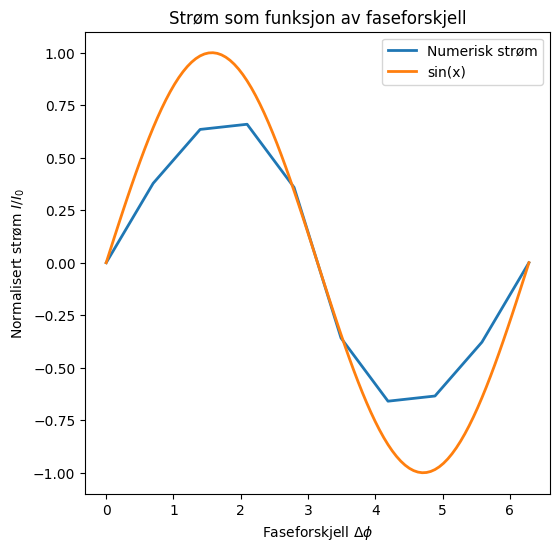

In [244]:
phiL_vals = np.linspace(0, 2*np.pi, 10)
epsilon_vals = np.linspace(0, 2, 101)

l = 1
II0_lst = []

# Itererer over faseforskjeller
for phiL in phiL_vals:
    phiR = 0
    
    x = np.linspace(0, l, m)
    y0 = np.zeros((32, m))
    solutions = {}

    # Løser for alle energier
    for epsilon in reversed(epsilon_vals):
        res = solve_bvp(
            lambda x, vec: fun(x, vec, epsilon),
            lambda vL, vR: bc_super(vL, vR, epsilon, phiL, phiR),
            x, y0
        )
        solutions[epsilon] = res.y
        y0 = res.sol(x)

    mid_idx = m // 2
    j_lst = []

    # Beregner strømintegranden i midten
    for epsilon in epsilon_vals:
        gamma, gamma_t, omega, omega_t = splitMatrices(solutions[epsilon][:, mid_idx])
        ghat = gh(gamma, gamma_t)
        dx_ghat = dx_gh(gamma, gamma_t, omega, omega_t)
        j_lst.append(j(ghat, dx_ghat))

    # Integrerer for å få strømverdiene
    II0 = -simpson(j_lst, epsilon_vals)
    II0_lst.append(II0)


# Sammenligning med sinusfunksjonen
x_plot = np.linspace(0, 2*np.pi, 100)

plt.plot(phiL_vals, II0_lst, label="Numerisk strøm")
plt.plot(x_plot, np.sin(x_plot), label="sin(x)")

plt.xlabel(r"Faseforskjell $\Delta \phi$")
plt.ylabel(r"Normalisert strøm $I/I_0$")
plt.title("Strøm som funksjon av faseforskjell")

plt.legend()
plt.grid()

plt.show()

Plottet viser strømmen $I/I_0$ som funksjon av faseendringen $\Delta \phi = \phi_L - \phi_R$. Sammenlignet med sinusfunksjonen er løsningen ganske lik, med litt mindre utslag, som stemmer ut i fra at vi forventer en periodisk funksjon. 
(Ikke ferdig)